
# SUPPORTLYTICS — MODULE 5 & 6 CODE


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA

In [21]:
df = pd.read_excel("Supportlytics_Cleaned_Dataset.xlsx")

In [22]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Age', 'Customer Gender',
       'Product Purchased', 'Date of Purchase', 'Ticket Type',
       'Ticket Subject', 'Ticket Status', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Category', 'Resolution_Duration',
       'Priority_Score', 'Cluster_Name', 'Cluster_ID'],
      dtype='object')


# Clean columns


In [23]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.rename(columns={
    "Ticket_Channel": "Channel",
    "Ticket_Priority": "Priority",
    "Date_of_Purchase": "Date"
}, inplace=True)

# 2. HANDLE MISSING VALUES

In [24]:
print("\nMissing Resolution_Duration BEFORE:", df['Resolution_Duration'].isnull().sum())

df = df.dropna(subset=['Resolution_Duration'])

print("Missing Resolution_Duration AFTER:", df['Resolution_Duration'].isnull().sum())


Missing Resolution_Duration BEFORE: 5700
Missing Resolution_Duration AFTER: 0


# 3. CREATE GEO DATA (FOR MAP)

In [25]:
countries = ['USA', 'India', 'UK', 'Germany', 'Canada']

df['Country'] = np.random.choice(countries, size=len(df))

country_coords = {
    'USA': (37.0902, -95.7129),
    'India': (20.5937, 78.9629),
    'UK': (55.3781, -3.4360),
    'Germany': (51.1657, 10.4515),
    'Canada': (56.1304, -106.3468)
}

df['Latitude'] = df['Country'].map(lambda x: country_coords[x][0])
df['Longitude'] = df['Country'].map(lambda x: country_coords[x][1])

# 4. PERFORMANCE ANALYSIS (MODULE 5)

In [26]:
priority_perf = df.groupby('Priority')['Resolution_Duration'].mean().sort_values()
category_perf = df.groupby('Category')['Resolution_Duration'].mean().sort_values()
channel_perf = df.groupby('Channel')['Resolution_Duration'].mean().sort_values()
cluster_perf = df.groupby('Cluster_Name')['Resolution_Duration'].mean().sort_values()

print("\nPriority Performance:\n", priority_perf)
print("\nCategory Performance:\n", category_perf)
print("\nChannel Performance:\n", channel_perf)
print("\nCluster Performance:\n", cluster_perf)



Priority Performance:
 Priority
Medium      11.552470
High        11.870614
Critical    12.010161
Low         12.463542
Name: Resolution_Duration, dtype: float64

Category Performance:
 Category
Billing             11.099868
Technical Issue     11.654554
Feature Request     11.964996
Order & Delivery    12.143134
Other               12.174112
Authentication      12.736930
Name: Resolution_Duration, dtype: float64

Channel Performance:
 Channel
Email           11.776275
Phone           11.862717
Chat            12.098494
Social media    12.136920
Name: Resolution_Duration, dtype: float64

Cluster Performance:
 Cluster_Name
High Priority Issues    11.810729
Fast & Satisfied        11.842031
Standard Service        12.299762
Name: Resolution_Duration, dtype: float64


# 5. SMART SLA THRESHOLD (FIXED)

In [27]:
# Use 75th percentile (data-driven threshold)
SLA_THRESHOLD = df['Resolution_Duration'].quantile(0.75)

df['SLA_Breach'] = df['Resolution_Duration'] > SLA_THRESHOLD

print("\nSLA Threshold (75th percentile):", SLA_THRESHOLD)
print("\nSLA Breach Distribution:\n", df['SLA_Breach'].value_counts())



SLA Threshold (75th percentile): 17.80805555555555

SLA Breach Distribution:
 SLA_Breach
False    2077
True      692
Name: count, dtype: int64


# 6. EFFICIENCY SCORE

In [28]:
df['Efficiency_Score'] = df['Priority_Score'] / df['Resolution_Duration']

# 7. VISUALS

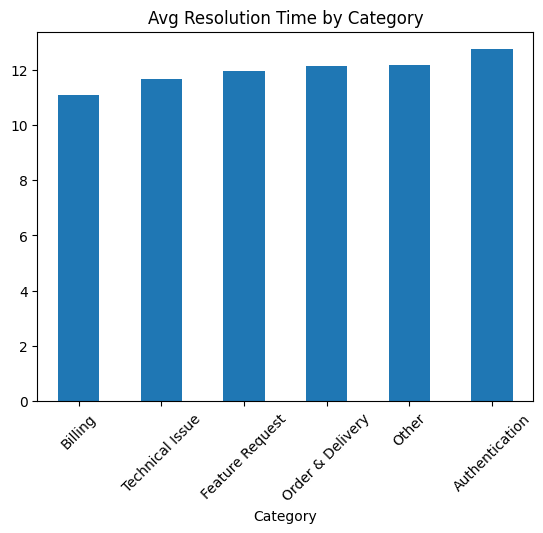

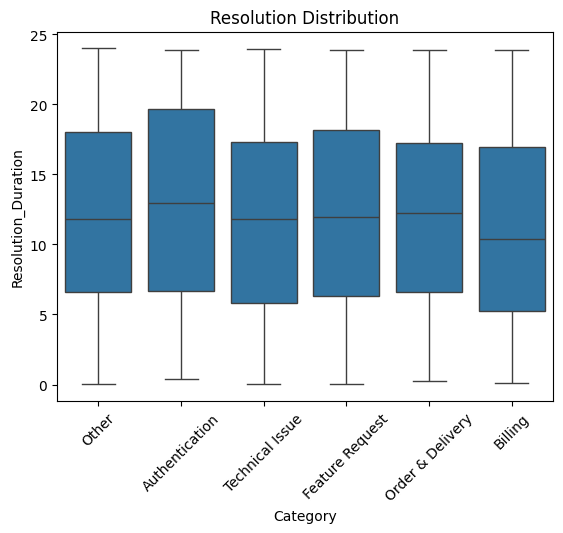

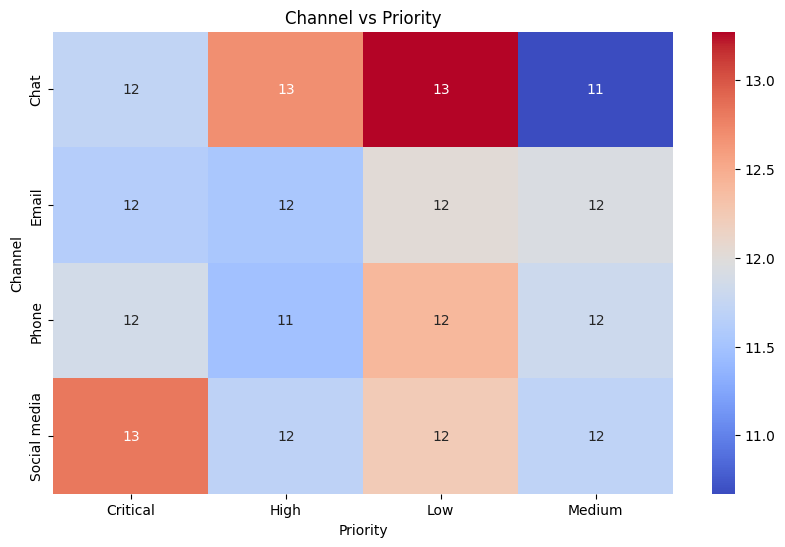

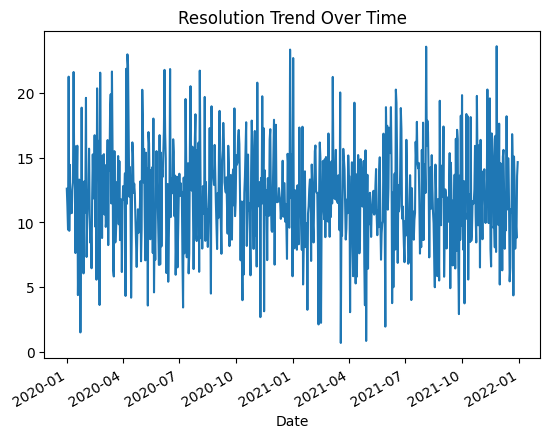

In [29]:

# Bar Chart
plt.figure()
category_perf.plot(kind='bar')
plt.title("Avg Resolution Time by Category")
plt.xticks(rotation=45)
plt.show()
print("\n")
# Boxplot
plt.figure()
sns.boxplot(x='Category', y='Resolution_Duration', data=df)
plt.xticks(rotation=45)
plt.title("Resolution Distribution")
plt.show()
print("\n")
# Heatmap
heatmap_data = df.pivot_table(
    values='Resolution_Duration',
    index='Channel',
    columns='Priority',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm')
plt.title("Channel vs Priority")
plt.show()
print("\n")
# Trend
trend = df.groupby('Date')['Resolution_Duration'].mean()

plt.figure()
trend.plot()
plt.title("Resolution Trend Over Time")
plt.show()
print("\n")

# 8.GEOGRAPHIC VISUALIZATION

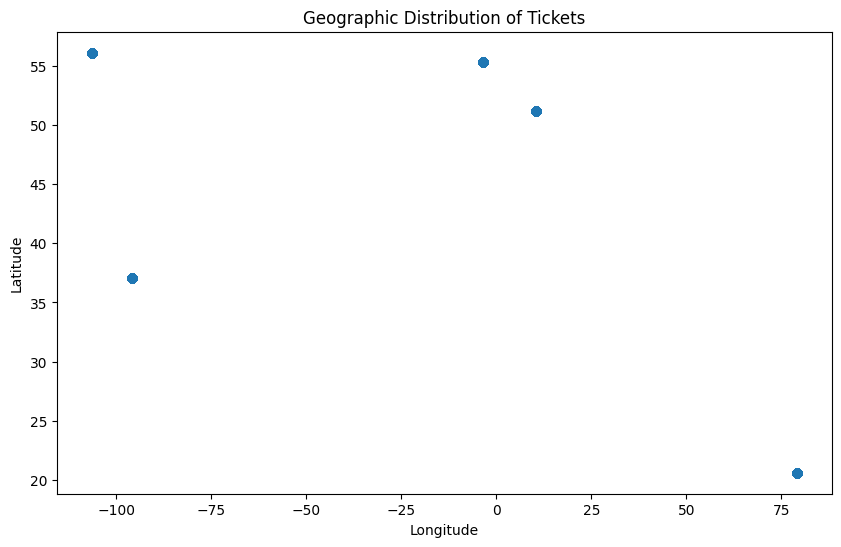

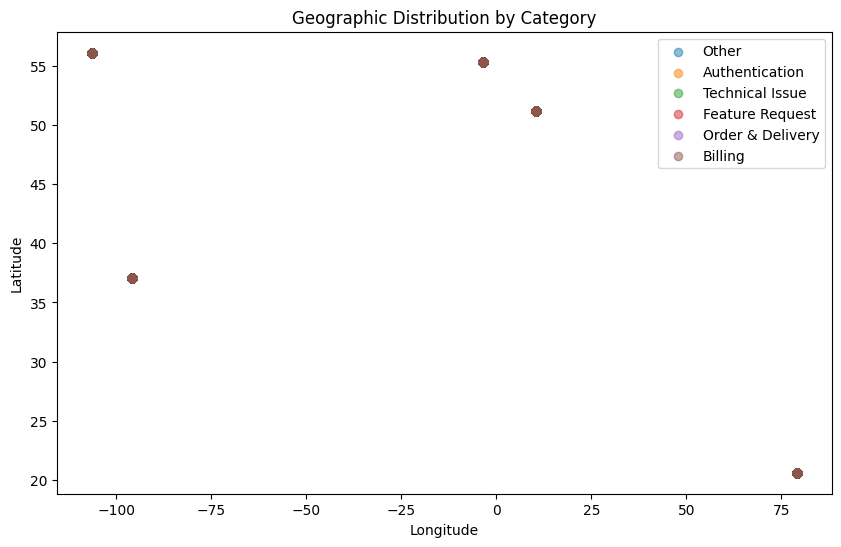

In [30]:
# Basic Map
plt.figure(figsize=(10,6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.5)
plt.title("Geographic Distribution of Tickets")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Category-wise Map
plt.figure(figsize=(10,6))
for category in df['Category'].unique():
    subset = df[df['Category'] == category]
    plt.scatter(subset['Longitude'], subset['Latitude'], label=category, alpha=0.5)

plt.legend()
plt.title("Geographic Distribution by Category")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 9. CLUSTER ANALYSIS

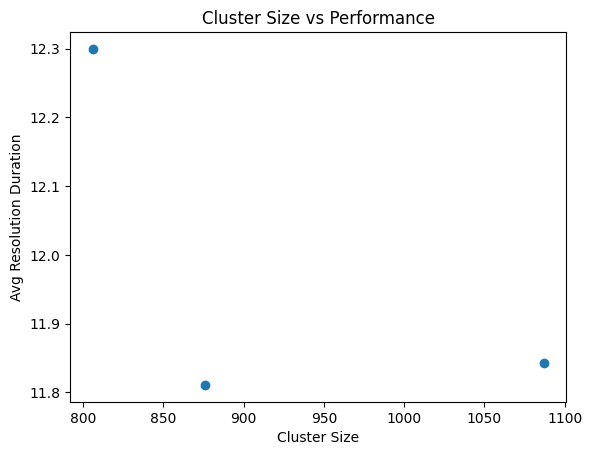

In [31]:
cluster_size = df.groupby('Cluster_Name').size()
cluster_time = df.groupby('Cluster_Name')['Resolution_Duration'].mean()

plt.figure()
plt.scatter(cluster_size, cluster_time)
plt.xlabel("Cluster Size")
plt.ylabel("Avg Resolution Duration")
plt.title("Cluster Size vs Performance")
plt.show()

# 10. EXPORT FINAL DATA FOR POWER BI

In [32]:
df.to_csv("Supportlytics_Final_Dataset_pb.csv", index=False)

print("\n✅ FINAL DATA EXPORTED SUCCESSFULLY")
print("🚀 MODULE 5 & 6 COMPLETED")

In [33]:
from google.colab import files
files.download('Supportlytics_Final_Dataset_pb.csv')
